In [ ]:
# ==========================================
#  INSTALL & IMPORTS
# ==========================================

!pip install -q tensorflow gdown scikit-learn opencv-python

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os, zipfile, gdown, cv2

from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121, EfficientNetV2B0
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ==========================================
# STEP 1: MOUNT GOOGLE DRIVE
# ==========================================

from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
# ==========================================
# STEP 2: DOWNLOAD DATASET
# ==========================================

file_id = "1mPOxf0Wnwqzeo6ZWFzISltAcyjIdxRRn"
url = f"https://drive.google.com/uc?id={file_id}"

if not os.path.exists("dataset.zip"):
    gdown.download(url, "dataset.zip", quiet=False)

if not os.path.exists("/content/dataset"):
    with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
        zip_ref.extractall("/content")

print("✅ Dataset ready")


Downloading...
From (original): https://drive.google.com/uc?id=1mPOxf0Wnwqzeo6ZWFzISltAcyjIdxRRn
From (redirected): https://drive.google.com/uc?id=1mPOxf0Wnwqzeo6ZWFzISltAcyjIdxRRn&confirm=t&uuid=2415c520-7f6a-4489-9eb6-1ac3135331fe
To: /content/dataset.zip
100%|██████████| 111M/111M [00:00<00:00, 113MB/s] 


✅ Dataset ready


In [ ]:
# ==========================================
# STEP 3: PARAMETERS
# ==========================================

IMG_SIZE = (224,224) #image preeprosesing
BATCH_SIZE = 16
EPOCHS_STAGE1 = 10
EPOCHS_STAGE2 = 10
AUTOTUNE = tf.data.AUTOTUNE


In [ ]:
# ==========================================
# STEP 4: LOAD DATASETS
# ==========================================

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/dataset/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/dataset/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/dataset/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)


Found 960 files belonging to 2 classes.
Found 180 files belonging to 2 classes.
Found 60 files belonging to 2 classes.


In [ ]:
# ==========================================
# STEP 5: DATA AUGMENTATION
# ==========================================

augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomBrightness(0.05),
])


In [ ]:
# ==========================================
# STEP 6: PREPROCESSING
# ==========================================

def preprocess(x, y, training=False):
    if training:
        x = augment(x, training=True)
    x = tf.keras.applications.densenet.preprocess_input(x)
    return x, y

train_ds = train_ds.map(lambda x,y: preprocess(x,y,True),
                        num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

val_ds   = val_ds.map(lambda x,y: preprocess(x,y),
                      num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

test_ds  = test_ds.map(lambda x,y: preprocess(x,y),
                       num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


In [ ]:
# ==========================================
# STEP 7: HYBRID MODEL
# ==========================================

inputs = layers.Input(shape=(224,224,3))

# DenseNet branch (fine textures)
dn_base = DenseNet121(include_top=False, weights="imagenet", input_tensor=inputs)
dn_base.trainable = False
dn = layers.GlobalAveragePooling2D()(dn_base.output)

# EfficientNetV2 branch (global patterns)
ef_base = EfficientNetV2B0(include_top=False, weights="imagenet", input_tensor=inputs)
ef_base.trainable = False
ef = layers.GlobalAveragePooling2D()(ef_base.output)

# Fusion
x = layers.Concatenate()([dn, ef])
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)
model.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 14,211,985 (54.21 MB)

 Trainable params: 1,250,561 (4.77 MB)

 Non-trainable params: 12,961,424 (49.44 MB)

In [ ]:
# ==========================================
# STEP 8: TRAIN STAGE 1
# ==========================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.AUC(name="auc"),
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1
)


Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 119s 939ms/step - accuracy: 0.6713 - auc: 0.7475 - loss: 0.6158 - precision: 0.7071 - recall: 0.5695 - val_accuracy: 0.6833 - val_auc: 0.8698 - val_loss: 0.5771 - val_precision: 0.9714 - val_recall: 0.3778
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 230ms/step - accuracy: 0.8275 - auc: 0.8961 - loss: 0.4322 - precision: 0.8210 - recall: 0.8018 - val_accuracy: 0.7722 - val_auc: 0.9057 - val_loss: 0.4284 - val_precision: 0.8101 - val_recall: 0.7111
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 228ms/step - accuracy: 0.8746 - auc: 0.9332 - loss: 0.3383 - precision: 0.8775 - recall: 0.8731 - val_accuracy: 0.8111 - val_auc: 0.9209 - val_loss: 0.3782 - val_precision: 0.7979 - val_recall: 0.8333
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 227ms/step - accuracy: 0.8678 - auc: 0.9438 - loss: 0.3137 - precision: 0.8609 - recall: 0.8802 - val_accuracy: 0.8278 - val_auc: 0.9236 - val_loss: 0.3686 - val_precision: 0.7980 - val_recall: 0.8778
Epoch 5/10
60/60 ━━━━━━━━━━

In [ ]:
# ==========================================
# STEP 9: FINE TUNING
# ==========================================

dn_base.trainable = True
ef_base.trainable = True

for layer in dn_base.layers[:-40]:
    layer.trainable = False
for layer in ef_base.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.AUC(name="auc"),
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")]
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2
)


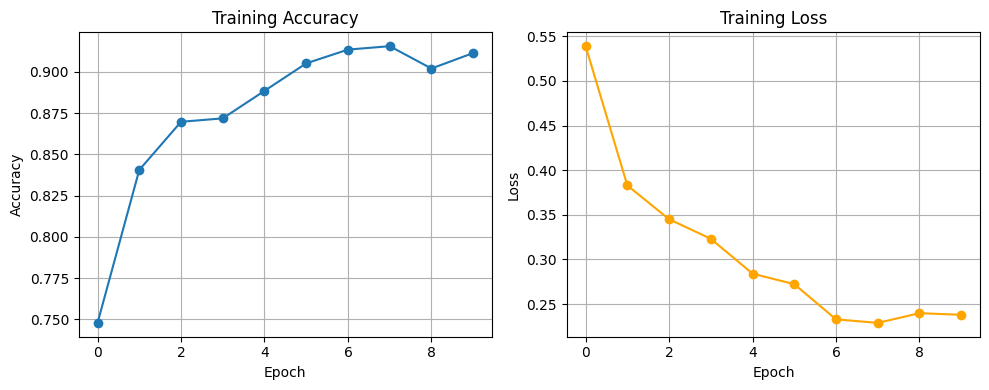

In [ ]:
# ==========================================
# TRAINING ACCURACY & TRAINING LOSS
# ==========================================

import matplotlib.pyplot as plt

epochs = range(len(history.history["loss"]))

plt.figure(figsize=(10,4))

# ---- Training Accuracy ----
plt.subplot(1,2,1)
plt.plot(epochs, history.history["accuracy"], marker="o")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

# ---- Training Loss ----
plt.subplot(1,2,2)
plt.plot(epochs, history.history["loss"], marker="o", color="orange")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.tight_layout()
plt.show()


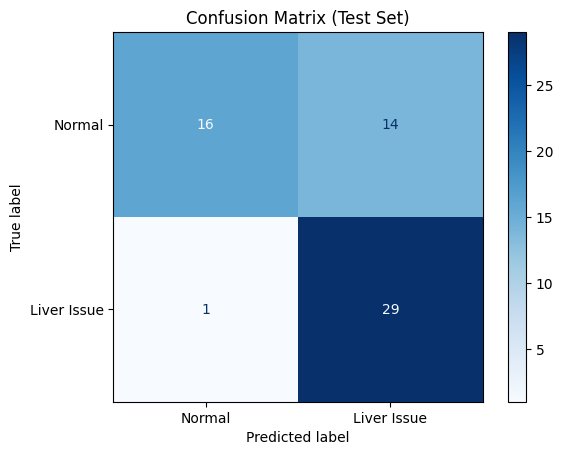

In [ ]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

y_true, y_pred = [], []

for imgs, labels in test_ds:
    preds = model.predict(imgs, verbose=0)
    preds = (preds >= 0.5).astype(int)
    y_pred.extend(preds.flatten())
    y_true.extend(labels.numpy().astype(int))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Liver Issue"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Test Set)")
plt.show()


In [ ]:
# ==========================================
# SINGLE IMAGE TEST (FINAL OUTPUT ONLY)
# ==========================================

from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

img = tf.keras.preprocessing.image.load_img(
    image_path, target_size=IMG_SIZE
)
img = tf.keras.preprocessing.image.img_to_array(img)
img = np.expand_dims(img, axis=0)
img = tf.keras.applications.densenet.preprocess_input(img)

score = model.predict(img)[0][0]

if score >= 0.5:
    print("FINAL RESULT : NORMAL")
else:
    print("FINAL RESULT : LIVER ISSUE")


In [ ]:
# ==========================================
# SAVE MODEL
# ==========================================

MODEL_DIR = "/content/drive/MyDrive/Iris_Liver_Models"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = f"{MODEL_DIR}/iris_liver_hybrid_effnetv2_densenet.keras"
model.save(model_path)

print("✅ Model saved to:", model_path)


✅ Model saved to: /content/drive/MyDrive/Iris_Liver_Models/iris_liver_hybrid_effnetv2_densenet.keras


In [ ]:
# ==========================================
# SAVE MODEL FOR FUTURE USE
# ==========================================

import os

MODEL_DIR = "/content/drive/MyDrive/Iris_Liver_Models"
os.makedirs(MODEL_DIR, exist_ok=True)

FINAL_MODEL_PATH = f"{MODEL_DIR}/iris_liver_hybrid_final.keras"

model.save(FINAL_MODEL_PATH)

print("✅ Model permanently saved at:")
print(FINAL_MODEL_PATH)

In [ ]:
# ==========================================
# AUTO SAVE BEST MODEL
# ==========================================

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=f"{MODEL_DIR}/best_iris_liver_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

earlystop_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[checkpoint_cb, earlystop_cb]
)


Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9196 - auc: 0.9751 - loss: 0.1989 - precision: 0.9100 - recall: 0.9295
Epoch 1: val_loss improved from inf to 0.27309, saving model to /content/drive/MyDrive/Iris_Liver_Models/best_iris_liver_model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 18s 283ms/step - accuracy: 0.9197 - auc: 0.9751 - loss: 0.1989 - precision: 0.9102 - recall: 0.9295 - val_accuracy: 0.8833 - val_auc: 0.9569 - val_loss: 0.2731 - val_precision: 0.8485 - val_recall: 0.9333
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.9114 - auc: 0.9767 - loss: 0.1959 - precision: 0.8995 - recall: 0.9320
Epoch 2: val_loss did not improve from 0.27309
60/60 ━━━━━━━━━━━━━━━━━━━━ 16s 253ms/step - accuracy: 0.9116 - auc: 0.9767 - loss: 0.1958 - precision: 0.8998 - recall: 0.9320 - val_accuracy: 0.8778 - val_auc: 0.9558 - val_loss: 0.2811 - val_precision: 0.8400 - val_recall: 0.9333
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.9076 - auc: 0.97

In [ ]:
# ==========================================
# LOAD SAVED MODEL (ANYTIME)
# ==========================================

import tensorflow as tf

MODEL_PATH = "/content/drive/MyDrive/Iris_Liver_Models/iris_liver_hybrid_effnetv2_densenet.keras"


model = tf.keras.models.load_model(MODEL_PATH)

print("✅ Model loaded and ready to use")


✅ Model loaded and ready to use


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Model loaded successfully")


✅ Model loaded successfully


In [ ]:

from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

img = tf.keras.preprocessing.image.load_img(
    image_path, target_size=(224,224)
)
img = tf.keras.preprocessing.image.img_to_array(img)
img = np.expand_dims(img, axis=0)
img = tf.keras.applications.densenet.preprocess_input(img)

score = model.predict(img)[0][0]
print("Prediction score:", score)

if score >= 0.5:
    print(" Normal")
else:
    print("Liver Issue ")

Saving 1_ (3).jpeg to 1_ (3).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 28s 28s/step
Prediction score: 0.00052285485
🟢 Normal
